In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kausthubkannan/ai-and-human-art-classification")

print("Path to dataset files:", path)

100%|██████████| 2.21G/2.21G [00:22<00:00, 103MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kausthubkannan/ai-and-human-art-classification/versions/1


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("superpotato9/dalle-recognition-dataset")

print("Path to dataset files:", path)

100%|██████████| 13.4G/13.4G [02:49<00:00, 84.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/superpotato9/dalle-recognition-dataset/versions/7


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sankarmechengg/art-images-clear-and-distorted")

print("Path to dataset files:", path)

 59%|█████▉    | 53.8G/90.9G [12:26<08:35, 77.4MB/s]


OSError: [Errno 28] No space left on device

In [ ]:
import os
import shutil
import random
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

In [ ]:
Image.MAX_IMAGE_PIXELS = 300000000

fakeV2 = pathlib.Path('/root/.cache/kagglehub/datasets/kausthubkannan/ai-and-human-art-classification/versions/1/ai_art_classification/train/AI_GENERATED')
real1 = pathlib.Path('/root/.cache/kagglehub/datasets/superpotato9/dalle-recognition-dataset/versions/7/real')
real2 = pathlib.Path('/root/.cache/kagglehub/datasets/kausthubkannan/ai-and-human-art-classification/versions/1/ai_art_classification/train/NON_AI_GENERATED')

data_dirs = {
    "AiArt": [fakeV2],
    "RealArt": [real1, real2]
}

def count_images(directories):
    total_count = 0
    image_files = []
    for directory in directories:
        images = list(directory.glob('*'))
        image_files.extend(images)
    return image_files

aiart_images = count_images(data_dirs['AiArt'])
realart_images = count_images(data_dirs['RealArt'])

print(f"AI-generated images (AiArt): {len(aiart_images)}")
print(f"Real images (RealArt): {len(realart_images)}")

AI-generated images (AiArt): 10330
Real images (RealArt): 12069


In [ ]:
def check_and_remove_large_images(directory):
    large_images = []
    problematic_images = []
    for img_path in directory.glob('*'):
        try:
            with Image.open(img_path) as img:
                # Check for extremely large images that might cause memory issues
                if img.size[0] * img.size[1] > Image.MAX_IMAGE_PIXELS:
                    large_images.append(str(img_path))
                img.verify() # Verify image integrity
        except (IOError, SyntaxError) as e:
            # Catch corrupted images
            print(f"Problematic image identified: {img_path}, Error: {e}")
            problematic_images.append(str(img_path))
        except Exception as e:
            print(f"Unexpected error with image: {img_path}, Error: {e}")
            problematic_images.append(str(img_path))
    return large_images, problematic_images

In [ ]:
image_paths = []
labels = []
large_images_list = []
problematic_images_list = []

for category, dirs in data_dirs.items():
    for category_path in dirs:
        print(f"Checking images in {category_path}")
        images = list(category_path.glob('*.jpg')) + list(category_path.glob('*.png'))

        for img_path in images:
            try:
                with Image.open(img_path) as img:
                    img.verify()
                    image_paths.append(img_path)
                    labels.append(category)
            except (IOError, SyntaxError) as e:
                print(f"Corrupted image: {img_path}, Error: {e}")
                problematic_images_list.append(img_path)

for dirs in data_dirs.values():
    for dir_path in dirs:
        large_images, problematic_images = check_and_remove_large_images(dir_path)
        large_images_list.extend(large_images)
        problematic_images_list.extend(problematic_images)

filtered_image_paths = []
filtered_labels = []

for path, label in zip(image_paths, labels):
    if str(path) not in large_images_list and str(path) not in problematic_images_list:
        filtered_image_paths.append(str(path))
        filtered_labels.append(label)

image_paths = np.array(filtered_image_paths)
labels = np.array(filtered_labels)

if len(image_paths) != len(labels):
    raise ValueError(f"Length mismatch: {len(image_paths)} images and {len(labels)} labels.")

Checking images in /root/.cache/kagglehub/datasets/kausthubkannan/ai-and-human-art-classification/versions/1/ai_art_classification/train/AI_GENERATED
Checking images in /root/.cache/kagglehub/datasets/superpotato9/dalle-recognition-dataset/versions/7/real
Checking images in /root/.cache/kagglehub/datasets/kausthubkannan/ai-and-human-art-classification/versions/1/ai_art_classification/train/NON_AI_GENERATED
Problematic image identified: /root/.cache/kagglehub/datasets/superpotato9/dalle-recognition-dataset/versions/7/real/r-art.txt, Error: cannot identify image file '/root/.cache/kagglehub/datasets/superpotato9/dalle-recognition-dataset/versions/7/real/r-art.txt'


In [ ]:
image_paths = aiart_images + realart_images
labels = ['AiArt'] * len(aiart_images) + ['RealArt'] * len(realart_images)

image_paths = [str(path) for path in image_paths]

data = pd.DataFrame({"filename": image_paths, "class": labels})

min_size = min(data['class'].value_counts())

balanced_data = data.groupby('class').apply(lambda x: x.sample(min_size)).reset_index(drop=True)

train_val_data, test_data = train_test_split(balanced_data, test_size=0.10, random_state=42, shuffle=True)

train_data, val_data = train_test_split(train_val_data, test_size=0.11, random_state=42, shuffle=True)  # 10% of 90% ≈ 10%

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='reflect'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_data,
    x_col="filename",
    y_col="class",
    target_size=(224, 224),
    class_mode='binary',
    batch_size=200
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_data,
    x_col="filename",
    y_col="class",
    target_size=(224, 224),
    class_mode='binary',
    batch_size=200
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_data,
    x_col="filename",
    y_col="class",
    target_size=(224, 224),
    class_mode='binary',
    batch_size=200
)

# Print dataset sizes for confirmation
print(f"Training set size: {len(train_data)}")
print(f"Validation set size: {len(val_data)}")
print(f"Test set size: {len(test_data)}")

Found 16548 validated image filenames belonging to 2 classes.
Found 2045 validated image filenames belonging to 2 classes.
Found 2066 validated image filenames belonging to 2 classes.
Training set size: 16548
Validation set size: 2046
Test set size: 2066


/tmp/ipykernel_18297/3253754128.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_data = data.groupby('class').apply(lambda x: x.sample(min_size)).reset_index(drop=True)
/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 1 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(


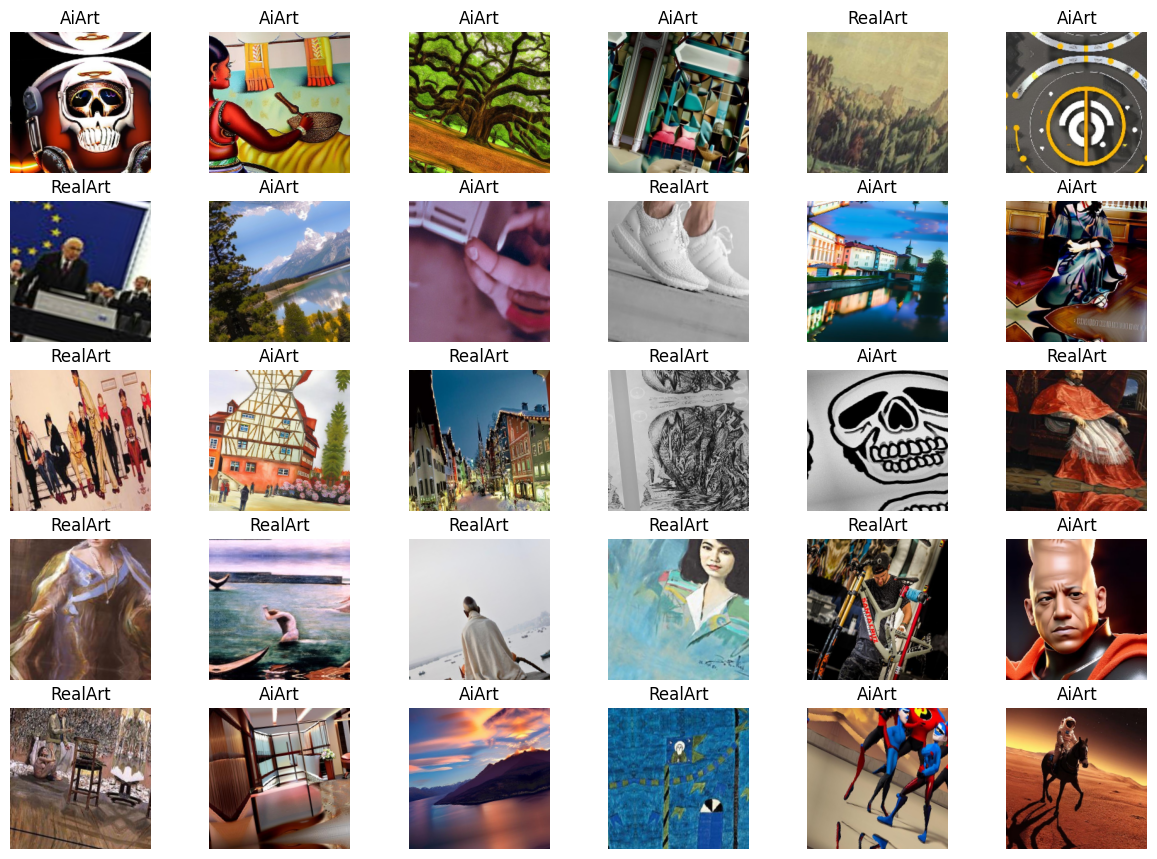

In [ ]:
images, labels = next(train_generator)
class_names = list(train_generator.class_indices.keys())

plt.figure(figsize=(15, 15))

for i in range(30):
    ax = plt.subplot(7, 6, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[int(labels[i])])
    plt.axis("off")

plt.show()

In [ ]:
base_model_v1 = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

base_model_v1.summary()

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenet_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,228,864 (12.32 MB)

 Trainable params: 3,206,976 (12.23 MB)

 Non-trainable params: 21,888 (85.50 KB)

In [ ]:
x = base_model_v1.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model_v1.input, outputs=predictions)

base_model_v1.trainable = True
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

checkpoint = ModelCheckpoint('MobileNetV1_finetuned_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1, min_lr=1e-10)

history_v1 = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    epochs=20,
    callbacks=[checkpoint, reduce_lr]
)


Epoch 1/20
12/82 ━━━━━━━━━━━━━━━━━━━━ 3:43 3s/step - accuracy: 0.4776 - loss: 1.0464

KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_v1.history['accuracy'])
plt.plot(history_v1.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.subplot(1, 2, 2)
plt.plot(history_v1.history['loss'])
plt.plot(history_v1.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()


In [ ]:
model = load_model('/kaggle/working/MobileNetV1_finetuned_model.keras')

test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


In [ ]:
IMAGE_SIZE = (224, 224)

def preprocess_image(image):
    if image.mode == 'RGBA':
        image = image.convert('RGB')
    image = image.resize(IMAGE_SIZE)
    image = img_to_array(image)
    image = np.expand_dims(image, axis=0)
    image = image / 255.0
    return image

def make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv_pw_13_relu", pred_index=None):
    last_conv_layer = model.get_layer(last_conv_layer_name)

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(image_path, heatmap, alpha=0.4):
    img = cv2.imread(image_path)
    img = cv2.resize(img, IMAGE_SIZE)

    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = heatmap * alpha + img

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(superimposed_img.astype('uint8'), cv2.COLOR_BGR2RGB))
    plt.title("Grad-CAM")
    plt.show()

# Function to classify the image
def classify_image(image_data, model):
    processed_image = preprocess_image(image_data)
    prediction = model.predict(processed_image)
    class_label = np.round(prediction[0][0]).astype(int)
    confidence = prediction[0][0]
    return class_label, confidence, processed_image

image_path = '/kaggle/input/ai-and-human-art-classification/ai_art_classification/test/10018.jpg'

img = Image.open(image_path)

class_label, confidence, processed_image = classify_image(img, model)
print(f"Predicted Class: {class_label}, Confidence: {confidence * 100:.2f}%")

heatmap = make_gradcam_heatmap(processed_image, model)

display_gradcam(image_path, heatmap)


In [ ]:
model.save("MobileNetV1_finetuned_model(0.95 loss 0.11).keras")